### **Decision Tree Classifier**

In [2]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [3]:
from sklearn.datasets import load_iris


In [4]:
iris=load_iris()

In [5]:
X=pd.DataFrame(iris['data'],columns=['sepal_lenght','sepal_width','petal_length','petal_width'])

In [6]:
#dependent features
y=iris['target']

In [7]:
#train test split
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,train_size=0.2,random_state=10)

In [ ]:
#you dont need standardization and normalization in decision tree 
#apply decision tree classifier
from sklearn.tree import DecisionTreeClassifier
treeclassifier=DecisionTreeClassifier(max_depth=2)# fixing the max depth post prunning

In [9]:
treeclassifier.fit(X_train,y_train)


,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


[Text(0.6, 0.8333333333333334, 'x[3] <= 1.75\ngini = 0.66\nsamples = 30\nvalue = [9, 9, 12]'),
 Text(0.4, 0.5, 'x[3] <= 0.7\ngini = 0.5\nsamples = 18\nvalue = [9, 9, 0]'),
 Text(0.5, 0.6666666666666667, 'True  '),
 Text(0.2, 0.16666666666666666, 'gini = 0.0\nsamples = 9\nvalue = [9, 0, 0]'),
 Text(0.6, 0.16666666666666666, 'gini = 0.0\nsamples = 9\nvalue = [0, 9, 0]'),
 Text(0.8, 0.5, 'gini = 0.0\nsamples = 12\nvalue = [0, 0, 12]'),
 Text(0.7, 0.6666666666666667, '  False')]

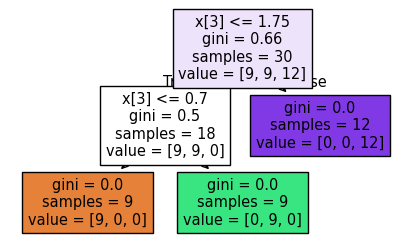

In [10]:
#vizualize the decision tree
from sklearn import tree
plt.figure(figsize=(5,3))
tree.plot_tree(treeclassifier,filled=True)


In [11]:
#pre prunning and post prunning 

In [12]:
y_pred=treeclassifier.predict(X_test)


In [13]:
from sklearn.metrics import confusion_matrix,classification_report

In [14]:
cm=confusion_matrix(y_test,y_pred)
print(cm)
print(classification_report(y_test,y_pred))

[[41  0  0]
 [ 0 40  1]
 [ 0  5 33]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        41
           1       0.89      0.98      0.93        41
           2       0.97      0.87      0.92        38

    accuracy                           0.95       120
   macro avg       0.95      0.95      0.95       120
weighted avg       0.95      0.95      0.95       120



* post prunning is good for smaller dataset
* best way is to do pre prunning 

### **Preprunning**

In [16]:
params={
    'criterion':['gini','entropy','log_loss'],
    'splitter':['best','random'],
    'max_depth':[1,2,3,4,5],
    'max_features':['auto','sqrt','log2']
}

In [17]:
from sklearn.model_selection import GridSearchCV

In [18]:
treemodel=DecisionTreeClassifier()


In [19]:
grid=GridSearchCV(treeclassifier,param_grid=params,cv=5,scoring='accuracy')

In [20]:
grid.fit(X_train,y_train)

/home/dazai/Yash/Data_sci/Machine_learn/.conda/lib/python3.11/site-packages/sklearn/model_selection/_validation.py:516: FitFailedWarning: 
150 fits failed out of a total of 450.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
150 fits failed with the following error:
Traceback (most recent call last):
  File "/home/dazai/Yash/Data_sci/Machine_learn/.conda/lib/python3.11/site-packages/sklearn/model_selection/_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/home/dazai/Yash/Data_sci/Machine_learn/.conda/lib/python3.11/site-packages/sklearn/base.py", line 1358, in wrapper
    estimator._validate_params()
  File "/home/dazai/Yash/Data_sci/Machine_learn/.conda/lib/python3.11/site-packages/

,estimator,DecisionTreeClassifier()
,param_grid,"{'criterion': ['gini', 'entropy', ...], 'max_depth': [1, 2, ...], 'max_features': ['auto', 'sqrt', ...], 'splitter': ['best', 'random']}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


In [21]:
grid.best_params_

{'criterion': 'gini',
 'max_depth': 3,
 'max_features': 'sqrt',
 'splitter': 'best'}

In [22]:
grid.best_score_

np.float64(0.9666666666666668)

In [23]:
y_pred=grid.predict(X_test)

In [24]:
cm=confusion_matrix(y_test,y_pred)
print(cm)
print(classification_report(y_test,y_pred))


[[41  0  0]
 [ 0 40  1]
 [ 0  5 33]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        41
           1       0.89      0.98      0.93        41
           2       0.97      0.87      0.92        38

    accuracy                           0.95       120
   macro avg       0.95      0.95      0.95       120
weighted avg       0.95      0.95      0.95       120



In [25]:
from sklearn.metrics import accuracy_score
score=accuracy_score(y_test,y_pred)

In [26]:
score

0.95